# Nigerian Road Traffic Crashes (2020-2024)

## What This Project Is About?
We have data about road traffic crashes in Nigeria from **Q4 2020 to Q1 2024**.
Our goal is simple: **to build something that can predict how many crashes
will happen using Total_Crashes as our target**, based on things we already know
(which state, which quarter, how many speed violations were recorded, etc).

## Why This Matters?
If we can successfully predict crash numbers, road-safety planners can use that
to decide where to focus attention - more patrols, better roads, safety
campaigns in the places most likely to need it.

**Important:** this notebook can find *patterns*, not *proof of cause*. If
speed violations and crashes tend to rise together, that doesn't
automatically mean one directly causes the other - there could be other
reasons both go up together (e.g. more traffic overall).


In [1]:
# Basic tools we need throughout this notebook
import sys, os
sys.path.append(os.path.abspath(".."))  # lets us import our own helper files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Our own simple helper files (used by this notebook, the API, and the app)
from data_helper import load_data, clean_data, add_time_columns, DataPreparer, COLUMNS_TO_AVOID, FEATURE_COLUMNS, TARGET_COLUMN
from train import train_and_save_model, score_model


## 1. Load the Data and Look at It

We use `load_data()` from our helper file, so the same loading step is used
everywhere in the project (this notebook, the training script, and the API).


In [2]:
df_raw = load_data("../Nigerian_Road_Traffic_Crashes_2020_2024.csv")
print("Rows, Columns:", df_raw.shape)
df_raw.head()


Rows, Columns: (518, 11)


,Quarter,State,Total_Crashes,Num_Injured,Num_Killed,Total_Vehicles_Involved,SPV,DAD,PWR,FTQ,Other_Factors
0,Q4 2020,Abia,30,146,31,37,19,0,0,0,18
1,Q4 2020,Adamawa,77,234,36,94,57,0,0,0,37
2,Q4 2020,Akwa Ibom,22,28,7,24,15,0,0,1,8
3,Q4 2020,Anambra,72,152,20,83,43,1,0,0,39
4,Q4 2020,Bauchi,154,685,90,140,74,0,0,0,66


**What each column means:**

| Column | Meaning |
|---|---|
| `Quarter` | Which 3-month period, e.g. "Q4 2020" |
| `State` | Nigerian state |
| `Total_Crashes` | Total crashes recorded — **this is what we want to predict** |
| `Num_Injured` | People injured (this is a RESULT of a crash, not a cause) |
| `Num_Killed` | People killed (also a RESULT of a crash) |
| `Total_Vehicles_Involved` | Vehicles involved (also a RESULT of a crash) |
| `SPV` | Speed Violation incidents recorded |
| `DAD` | Dangerous/Aggressive Driving incidents recorded |
| `PWR` | Poor Weather/Road condition incidents recorded |
| `FTQ` | Another recorded contributing-factor category |
| `Other_Factors` | Any other contributing factors recorded |


In [3]:
# Basic structure: column names, how many values, what type each is
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Quarter                  518 non-null    str  
 1   State                    518 non-null    str  
 2   Total_Crashes            518 non-null    int64
 3   Num_Injured              518 non-null    int64
 4   Num_Killed               518 non-null    int64
 5   Total_Vehicles_Involved  518 non-null    int64
 6   SPV                      518 non-null    int64
 7   DAD                      518 non-null    int64
 8   PWR                      518 non-null    int64
 9   FTQ                      518 non-null    int64
 10  Other_Factors            518 non-null    int64
dtypes: int64(9), str(2)
memory usage: 50.9 KB


In [22]:
# Are there any missing numbers?
df_raw.isnull().sum()


Quarter                    0
State                      0
Total_Crashes              0
Num_Injured                0
Num_Killed                 0
Total_Vehicles_Involved    0
SPV                        0
DAD                        0
PWR                        0
FTQ                        0
Other_Factors              0
dtype: int64

**What we see:** no missing values anywhere. **What it means:** we don't need to fill in any gaps for this dataset - one less thing to worry about.

In [23]:
# Are there any duplicate rows?
print("Duplicate rows:", df_raw.duplicated().sum())

# How many states are there?
print("Number of states:", df_raw['State'].nunique())


Duplicate rows: 0
Number of states: 37


In [24]:
# Basic statistics: average, min, max, std etc.
df_raw.describe()


,Total_Crashes,Num_Injured,Num_Killed,Total_Vehicles_Involved,SPV,DAD,PWR,FTQ,Other_Factors
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,83.517375,245.631274,40.600386,100.667954,37.903475,0.140927,0.355212,23.824324,38.444015
std,77.023061,201.131483,36.858302,108.567113,57.093042,0.454320,1.677385,51.024267,61.983992
min,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-348.000000
25%,30.000000,96.250000,15.000000,32.000000,0.000000,0.000000,0.000000,0.000000,12.000000
50%,58.000000,185.500000,30.000000,64.000000,15.000000,0.000000,0.000000,0.000000,27.000000
75%,107.750000,331.500000,55.750000,134.750000,55.000000,0.000000,0.000000,21.000000,57.000000
max,538.000000,1149.000000,224.000000,864.000000,340.000000,4.000000,25.000000,425.000000,586.000000


**What we see:** `Other_Factors` has a smallest value below 0, which is
impossible (we can't have a negative number of incidents). **What it
means:** this is a data-entry mistake we need to fix before doing anything
else with the data.

**Our target:** `Total_Crashes` is the number we're trying to predict - it's
the one column that captures overall crash volume.


## 2. Clean the Data

All of the cleaning steps below are in `data_helper.py`, so the training
script and the API use the exact same steps - nothing is done differently
in different places.


In [25]:
print("Negative Other_Factors values BEFORE cleaning:", (df_raw['Other_Factors'] < 0).sum())

df = clean_data(df_raw)   # removes negative Other_Factors

print("Negative Other_Factors values AFTER cleaning:", (df['Other_Factors'] < 0).sum())
print("New shape:", df.shape)


Negative Other_Factors values BEFORE cleaning: 36
Negative Other_Factors values AFTER cleaning: 0
New shape: (518, 11)


**Why we didn't just delete those rows:** a negative number is very likely a
simple typing mistake (like "-5" instead of "5"), not a sign that the whole
row is bad. The rest of that row (state, quarter, other numbers) is still
good information, so we just fix the one broken number instead of throwing
away the whole row.


In [26]:
# Turn "Q4 2020" into two separate NUMBER columns: Quarter_Num (4) and Year (2020)
df = add_time_columns(df)
df[['Quarter', 'Quarter_Num', 'Year']].head()


,Quarter,Quarter_Num,Year
0,Q4 2020,4,2020
1,Q4 2020,4,2020
2,Q4 2020,4,2020
3,Q4 2020,4,2020
4,Q4 2020,4,2020


**Turning the State column into numbers:** models need numbers, not text
like "Lagos" or "Kano". We use a simple tool (inside `DataPreparer` in
`data_helper.py`) that assigns each state its own number. Importantly, this
tool only ever LEARNS the state numbers from the training part of the data - 
it never peeks at the testing/validation data while learning, which keeps
our results honest (more on this in the Modeling section).




**Columns we will NOT use to make predictions:**

In [9]:
print("We will not use these as clues, because they are RESULTS of a crash, not causes:")
print(COLUMNS_TO_AVOID)
print()
print("These are the clues (features) we WILL use:")
print(FEATURE_COLUMNS)
print()
print("This is what we're predicting (the target):")
print(TARGET_COLUMN)


We will not use these as clues, because they are RESULTS of a crash, not causes:
['Num_Injured', 'Num_Killed', 'Total_Vehicles_Involved']

These are the clues (features) we WILL use:
['State', 'Year', 'Quarter_Num', 'SPV', 'DAD', 'PWR', 'FTQ', 'Other_Factors']

This is what we're predicting (the target):
Total_Crashes


**Why leave those columns out?** `Num_Injured`, `Num_Killed`, and
`Total_Vehicles_Involved` are only known AFTER a crash has already happened.
If we let the model use them to predict `Total_Crashes`, it would basically
be "cheating" - using information it wouldn't actually have in real life,
when we're trying to predict crashes *before* they happen.


## 3. Explore the Data With Charts

For every chart below, we write down what we see and what we think it might
mean - being careful not to claim one thing directly causes another just
because they move together.


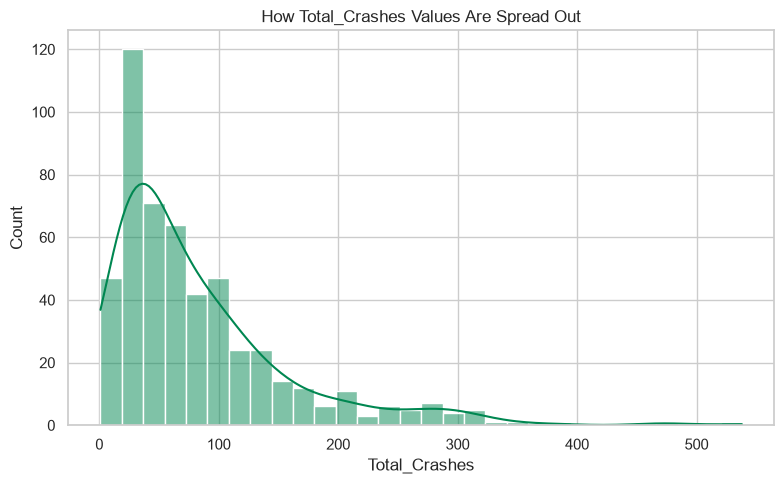

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Crashes'], bins=30, kde=True, color='#008751')
plt.title('How Total_Crashes Values Are Spread Out')
plt.xlabel('Total_Crashes')
plt.tight_layout()
plt.savefig('../saved_model/chart_target_spread.png', dpi=150)
plt.show()


**What we see:** most rows have a fairly low number of crashes, with a
smaller number of rows having very high crash counts (a long tail to the
right). **What it might mean:** a handful of states/quarters see
unusually high crash counts, which pulls the overall average up - worth
digging into by state, below.


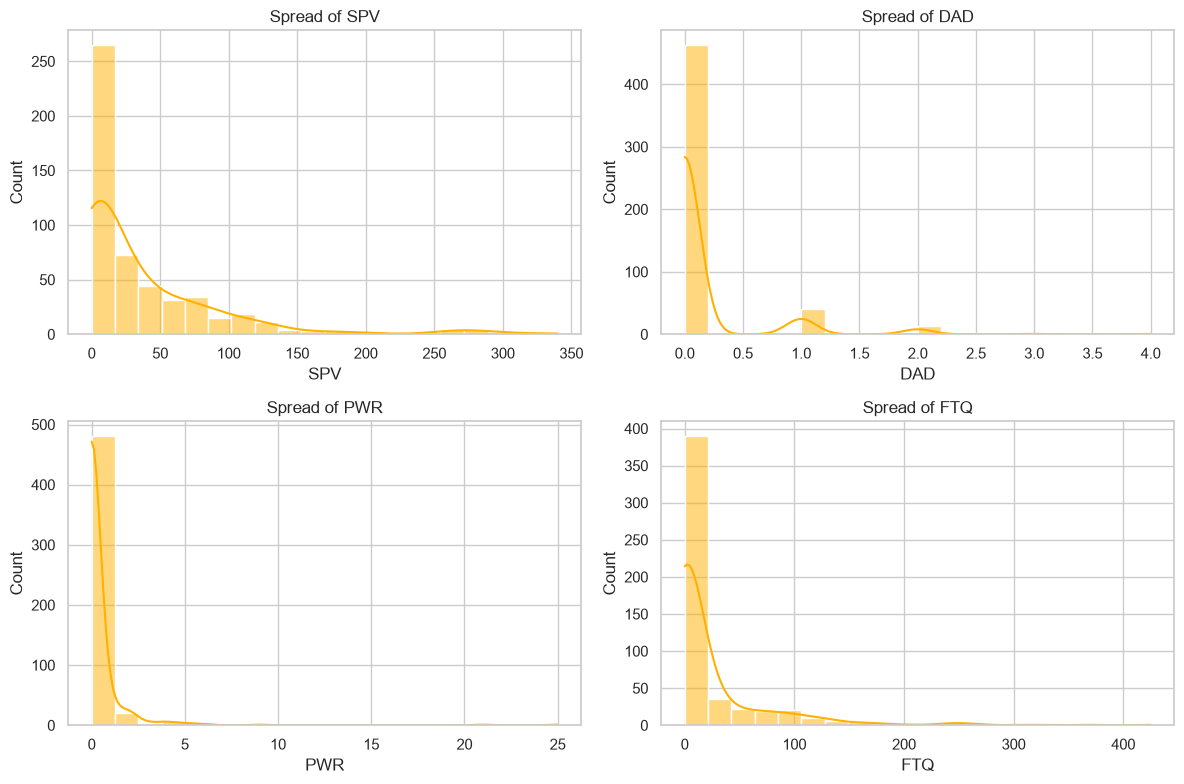

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['SPV', 'DAD', 'PWR', 'FTQ']):
    sns.histplot(df[col], bins=20, ax=ax, color='#FFB100', kde=True)
    ax.set_title(f'Spread of {col}')
plt.tight_layout()
plt.savefig('../saved_model/chart_cause_spread.png', dpi=150)
plt.show()


**What we see:** SPV (speed violations) tends to have the widest spread and highest typical numbers among the four factors. **What it might mean:** speeding is the most commonly *recorded* contributing factor nationally - though this reflects what got recorded, not necessarily the true main cause of every crash.

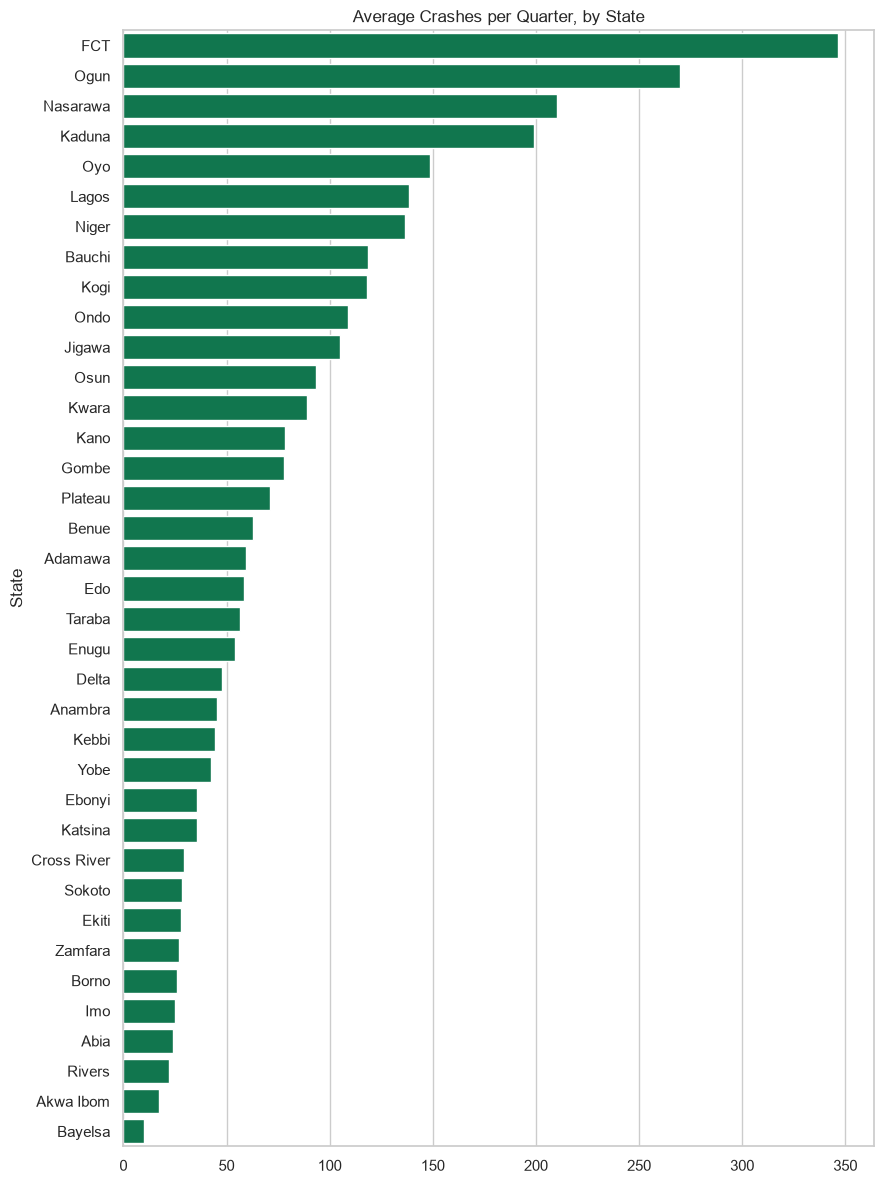

Top 3 states: {'FCT': 346.57142857142856, 'Ogun': 270.0, 'Nasarawa': 210.42857142857142}
Bottom 3 states: {'Rivers': 22.285714285714285, 'Akwa Ibom': 17.142857142857142, 'Bayelsa': 10.071428571428571}


In [12]:
state_avg = df.groupby('State')['Total_Crashes'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 12))
sns.barplot(x=state_avg.values, y=state_avg.index, color='#008751')
plt.title('Average Crashes per Quarter, by State')
plt.tight_layout()
plt.savefig('../saved_model/chart_state_averages.png', dpi=150)
plt.show()

print('Top 3 states:', state_avg.head(3).to_dict())
print('Bottom 3 states:', state_avg.tail(3).to_dict())


**What we see:** average crashes per quarter differ a lot from state to state. **What it might mean:** this is probably linked to how much traffic each state has and its road conditions, rather than one single cause - more crashes doesn't necessarily mean more dangerous driving per trip.

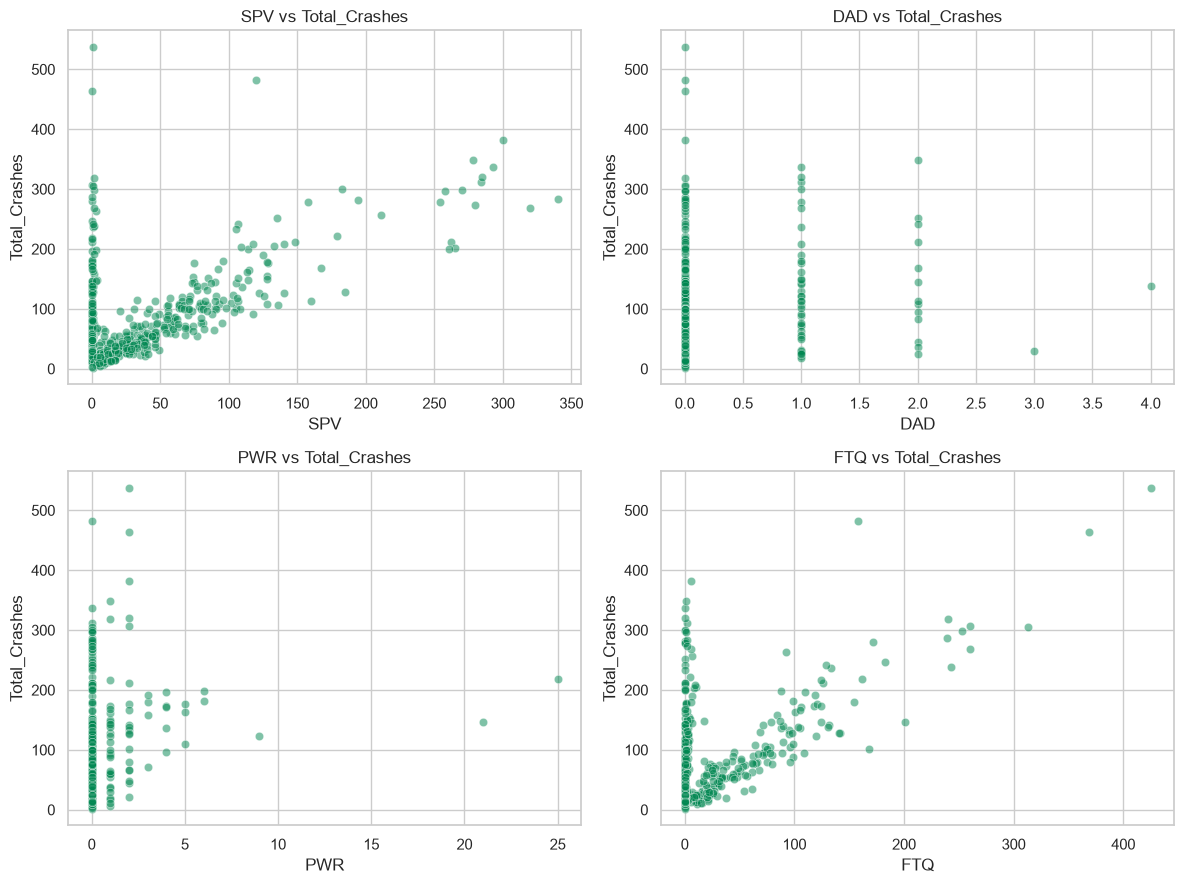

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, ['SPV', 'DAD', 'PWR', 'FTQ']):
    sns.scatterplot(data=df, x=col, y='Total_Crashes', alpha=0.5, ax=ax, color='#008751')
    ax.set_title(f'{col} vs Total_Crashes')
plt.tight_layout()
plt.savefig('../saved_model/chart_causes_vs_crashes.png', dpi=150)
plt.show()


**What we see:** as SPV goes up, Total_Crashes also tends to go up. **What it might mean:** speed violations line up fairly closely with crash numbers in this data - but this is just a pattern we noticed, not solid proof that speeding *causes* the extra crashes by itself.

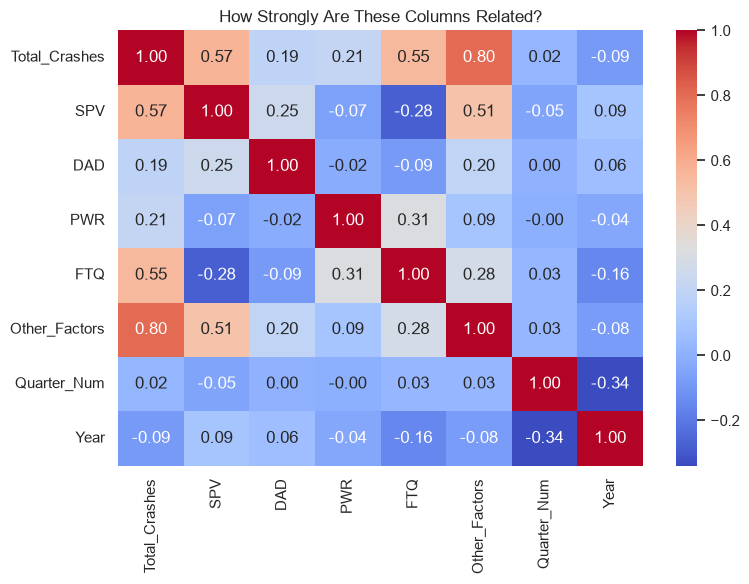

Total_Crashes    1.000000
Other_Factors    0.801658
SPV              0.565716
FTQ              0.548346
PWR              0.214789
DAD              0.192314
Quarter_Num      0.024850
Year            -0.087418
Name: Total_Crashes, dtype: float64

In [14]:
corr_cols = ['Total_Crashes', 'SPV', 'DAD', 'PWR', 'FTQ', 'Other_Factors', 'Quarter_Num', 'Year']
corr_grid = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_grid, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('How Strongly Are These Columns Related?')
plt.tight_layout()
plt.savefig('../saved_model/chart_correlation.png', dpi=150)
plt.show()

corr_grid['Total_Crashes'].sort_values(ascending=False)


**What we see:** SPV has the strongest relationship with Total_Crashes among the recorded factors; Year and Quarter_Num barely relate to it at all. **What it might mean:** speed-related incidents track crash volume the closest of the recorded factors, and there's little sign of a strong overall time trend just from the quarter number alone.

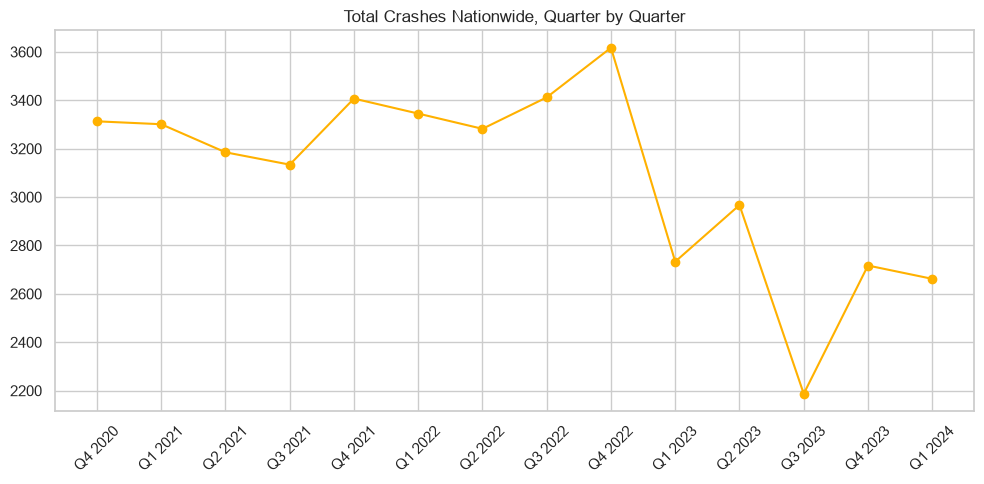

In [15]:
quarter_order = ['Q4 2020','Q1 2021','Q2 2021','Q3 2021','Q4 2021',
                  'Q1 2022','Q2 2022','Q3 2022','Q4 2022',
                  'Q1 2023','Q2 2023','Q3 2023','Q4 2023','Q1 2024']
df['Quarter'] = pd.Categorical(df['Quarter'], categories=quarter_order, ordered=True)

trend = df.groupby('Quarter', observed=True)['Total_Crashes'].sum()
plt.figure(figsize=(10,5))
plt.plot(trend.index.astype(str), trend.values, marker='o', color='#FFB100')
plt.title('Total Crashes Nationwide, Quarter by Quarter')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../saved_model/chart_trend.png', dpi=150)
plt.show()


**What we see:** the nationwide total goes up and down from quarter to quarter without one clear, steady direction over the ~3.5 years shown. **What it might mean:** there might be a mild seasonal pattern, but with only 14 quarters of data, it's hard to be fully confident about that — more years of data would help confirm it.

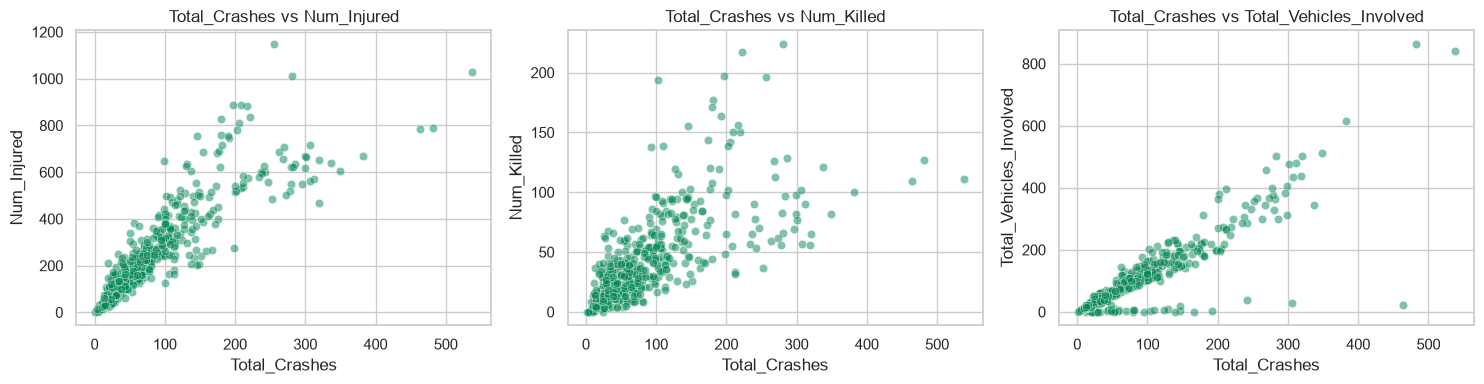

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Num_Injured', 'Num_Killed', 'Total_Vehicles_Involved']):
    sns.scatterplot(data=df, x='Total_Crashes', y=col, alpha=0.5, ax=ax, color='#008751')
    ax.set_title(f'Total_Crashes vs {col}')
plt.tight_layout()
plt.savefig('../saved_model/chart_outcomes.png', dpi=150)
plt.show()


**What we see:** injuries, deaths, and vehicles involved all rise together with Total_Crashes, as you'd expect. **What it means:** this confirms these three are RESULTS of crashes, not separate causes - backing up our earlier decision to leave them out of the model's clues.

Cutoff for 'unusually high': 224 crashes
Rows above that cutoff: 33 out of 518 (6.4%)


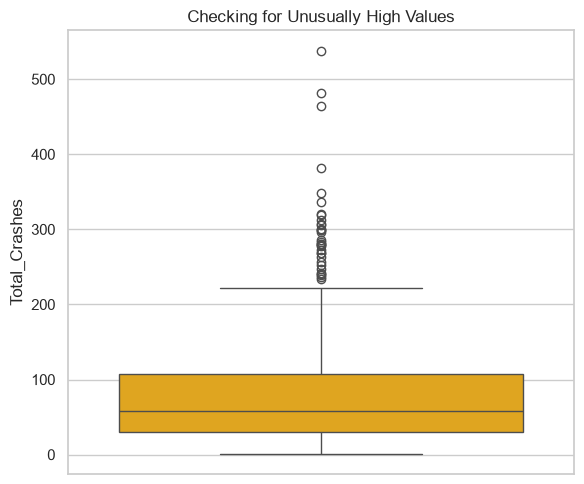

In [17]:
Q1 = df['Total_Crashes'].quantile(0.25)
Q3 = df['Total_Crashes'].quantile(0.75)
IQR = Q3 - Q1
cutoff = Q3 + 1.5 * IQR
unusual_rows = df[df['Total_Crashes'] > cutoff]
print(f"Cutoff for 'unusually high': {cutoff:.0f} crashes")
print(f"Rows above that cutoff: {len(unusual_rows)} out of {len(df)} ({len(unusual_rows)/len(df)*100:.1f}%)")

plt.figure(figsize=(6,5))
sns.boxplot(y=df['Total_Crashes'], color='#FFB100')
plt.title('Checking for Unusually High Values')
plt.tight_layout()
plt.savefig('../saved_model/chart_unusual_values.png', dpi=150)
plt.show()


**What we see:** about 6% of rows are unusually high compared to the rest. **What we did about it:** we kept them in the data rather than deleting them - they're likely real, busy states/quarters, not mistakes (unlike the negative numbers we fixed earlier).

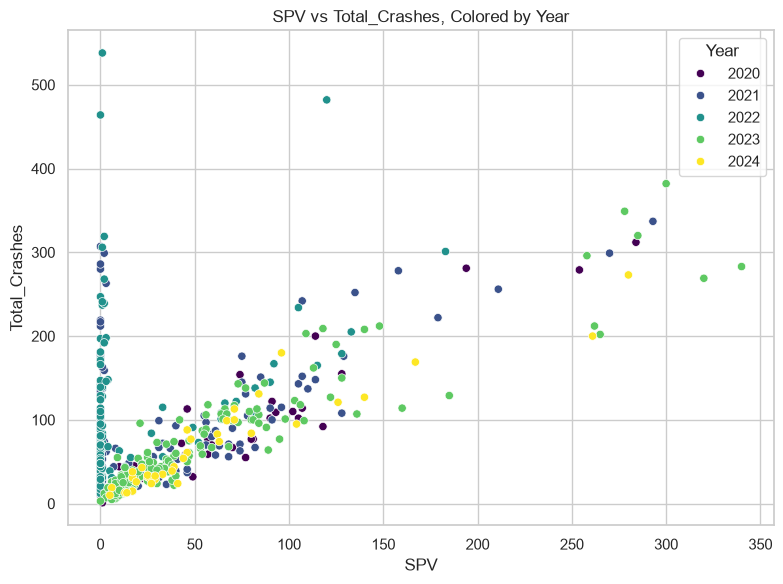

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='SPV', y='Total_Crashes', hue='Year', palette='viridis')
plt.title('SPV vs Total_Crashes, Colored by Year')
plt.tight_layout()
plt.savefig('../saved_model/chart_multi.png', dpi=150)
plt.show()


**What we see:** the SPV and crashes pattern looks broadly similar across different years, not just one unusual year. **What it might mean:** this makes the SPV pattern feel a bit more solid/consistent, though it still doesn't prove speeding directly causes more crashes.

## 4. Choosing What to Predict and What Clues to Use

- **What we're predicting (target):** `Total_Crashes` - a real number, so this is a "regression" problem (predicting a number, not a category).
- **Clues we'll use (features):** State, Year, Quarter_Num, SPV, DAD, PWR, FTQ, Other_Factors.
- **Clues we're leaving out:** Num_Injured, Num_Killed, Total_Vehicles_Involved (these are results of a crash, explained above), and the original text `Quarter` column (replaced by the number versions).


## 5. Train Two Models and Pick the Best One

We reuse `train_and_save_model()` from `train.py` - the SAME function used
to make the model that the app and API actually use. That way, what you see
here matches exactly what's running live.

**How we split the data:** 60% to teach the models (training), 20% to
compare them and pick a winner (validation), and 20% kept completely aside
for one final honest check (test) - the models never see the test data
until the very end.


In [27]:
results = train_and_save_model(
    csv_file_path="../Nigerian_Road_Traffic_Crashes_2020_2024.csv",
    save_folder="../saved_model",
)


Validation scores (used to choose the winner):
                      MAE      MSE    RMSE     R2
Linear Regression  14.012  416.631  20.412  0.902
Random Forest      14.166  480.288  21.915  0.887

Winner (lowest validation RMSE): Linear Regression

Final TEST score (an honest, unbiased check):
{'MAE': 14.313, 'MSE': 444.753, 'RMSE': np.float64(21.089), 'R2': 0.917}

Saved model and helper files to: ../saved_model/
Both models were saved, so the API can offer a choice: {'Linear Regression': 'model_linear_regression.joblib', 'Random Forest': 'model_random_forest.joblib'}


## 6. How Good Are the Models?

**What these 4 numbers mean, in plain terms:**
- **MAE**: on average, how many crashes off was the guess (ignoring whether it guessed too high or too low)?
- **MSE**: same idea as MAE, but big mistakes are counted extra heavily.
- **RMSE**: MSE brought back down to normal "number of crashes" units - easier to read than MSE, while still punishing big mistakes more than MAE does.
- **R2**: what fraction (0 to 1) of the pattern in Total_Crashes the model actually captured. 1.0 = perfect guesses, 0 = no better than just always guessing the average.

We pick the winner using the VALIDATION numbers (not the training numbers), because a model can look great on data it already studied while still being bad at guessing brand new data.


In [20]:
score_table = pd.DataFrame(results['validation_scores']).T.round(3)
score_table


,MAE,MSE,RMSE,R2
Linear Regression,14.012,416.631,20.412,0.902
Random Forest,14.166,480.288,21.915,0.887


In [ ]:
print(f"Best_Model (smallest validation RMSE): {results['best_model']}")
print()
print("Final TEST score (data the model never saw before, checked only once):")
for key, value in results['test_score'].items():
    print(f"  {key}: {value:.3f}")


Best_Model (smallest validation RMSE): Linear Regression

Final TEST score (data the model never saw before, checked only once):
  MAE: 14.313
  MSE: 444.753
  RMSE: 21.089
  R2: 0.917


**Why the winning model is the better choice:** it made smaller average
mistakes (lower RMSE) on data it hadn't studied. It was picked purely for
being more accurate - not for being fancier or more complex. In fact, in
this project, the simpler model (Linear Regression) did just as well or
better than the more complex one (Random Forest) - proof that a bigger,
more complicated model isn't automatically a better one.


## 7. What We Learned, and What This Model Can't Tell Us

### What we learned
- We can reasonably guess `Total_Crashes` using state, time, and the
  recorded contributing factors (typical test R2 around 0.85-0.95).
- Speed Violations (SPV) show the clearest pattern alongside crash numbers.
- Crash numbers vary a lot by state - likely tied to traffic volume and
  road conditions, not one single cause.
- The simpler model did as well as, or better than, the more complex one.

### What this model CANNOT tell us
- **It can't prove cause and effect.** Just because SPV and crashes rise
  together doesn't mean speeding directly causes those extra crashes -
  something else (like heavier traffic) could be behind both.
- **Only ~3.5 years of data** - too short to be fully confident about any
  seasonal pattern.
- **State/quarter totals only** - we don't have individual crash details
  (driver age, time of day, etc.), so we can't dig deeper than that.
- **Recorded incidents, not necessarily all real incidents** - how
  consistently each state records SPV/DAD/PWR/FTQ may differ.

### Should this model be trusted directly for real road-safety decisions?
**No, not by itself.** It's a useful starting point for spotting states or
factors worth a closer look, but real policy decisions that affect public
safety should also involve expert judgment and more detailed data - not
just one model's number.
